**Phase 1: Build and Baseline Your Model**



In [ ]:
# Import required libraries
!pip install shap lime folktables -q
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, ConfusionMatrixDisplay
)
import shap
!pip install ucimlrepo

In [ ]:
# Import the dataset
from ucimlrepo import fetch_ucirepo
# fetch dataset
adult = fetch_ucirepo(id=2)
# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets
# metadata
print(adult.metadata)
# variable information
print(adult.variables)


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [ ]:
# Combine everything into one dataframe for easier processing
import pandas as pd
df = pd.concat([X, y], axis=1)
# Preview first 5 rows of the dataset
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
# Drop missing values in the dataset
df = df.dropna()
# Convert income column into binary (1 = >50K, 0 = <=50K)
df["income"] = df["income"].apply(lambda x: 1 if ">50K" in str(x) else 0)
# Check dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47621 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             47621 non-null  int64 
 1   workclass       47621 non-null  object
 2   fnlwgt          47621 non-null  int64 
 3   education       47621 non-null  object
 4   education-num   47621 non-null  int64 
 5   marital-status  47621 non-null  object
 6   occupation      47621 non-null  object
 7   relationship    47621 non-null  object
 8   race            47621 non-null  object
 9   sex             47621 non-null  object
 10  capital-gain    47621 non-null  int64 
 11  capital-loss    47621 non-null  int64 
 12  hours-per-week  47621 non-null  int64 
 13  native-country  47621 non-null  object
 14  income          47621 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 5.8+ MB


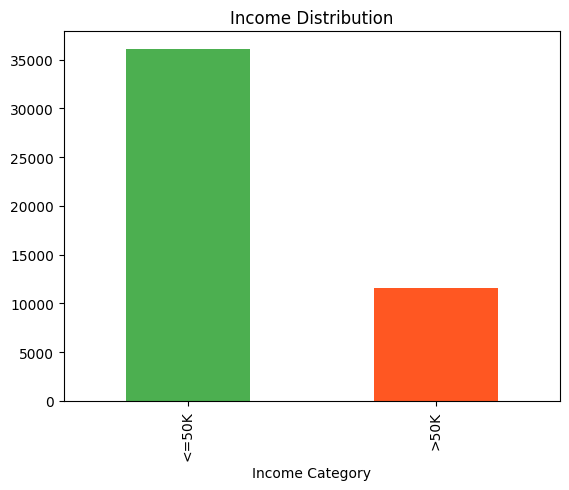

In [ ]:
# EDA
# Create a readable label column for income
df["income_label"] = df["income"].map({0: "<=50K", 1: ">50K"})
# Income distribution
df["income_label"].value_counts().plot(kind="bar",color=["#4CAF50", "#FF5722"])
plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.show()

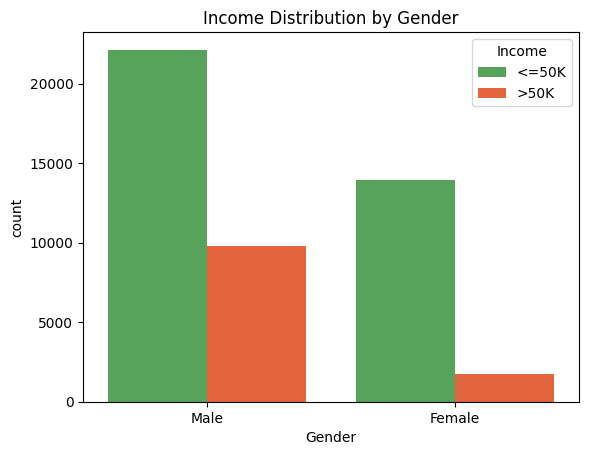

In [ ]:
# Income distribution by gender
sns.countplot(data=df,x="sex",hue="income_label",palette=["#4CAF50", "#FF5722"]  )
plt.title("Income Distribution by Gender")
plt.xlabel("Gender")
plt.legend(title="Income")
plt.show()

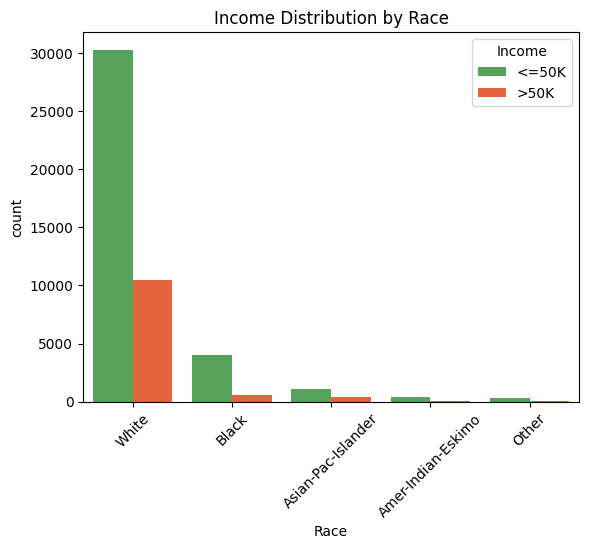

In [ ]:
# Income distribution by race
sns.countplot(data=df,x="race",hue="income_label",palette=["#4CAF50", "#FF5722"])
plt.title("Income Distribution by Race")
plt.xlabel("Race")
plt.xticks(rotation=45)
plt.legend(title="Income")
plt.show()

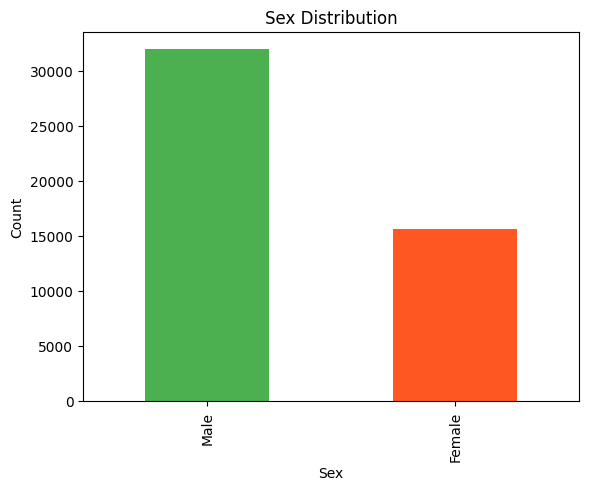

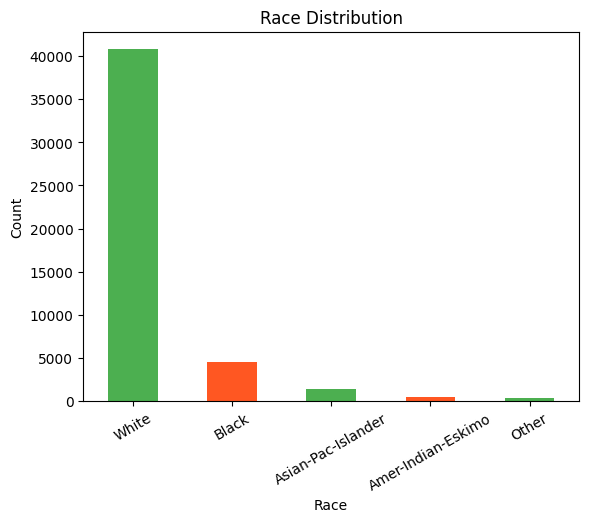

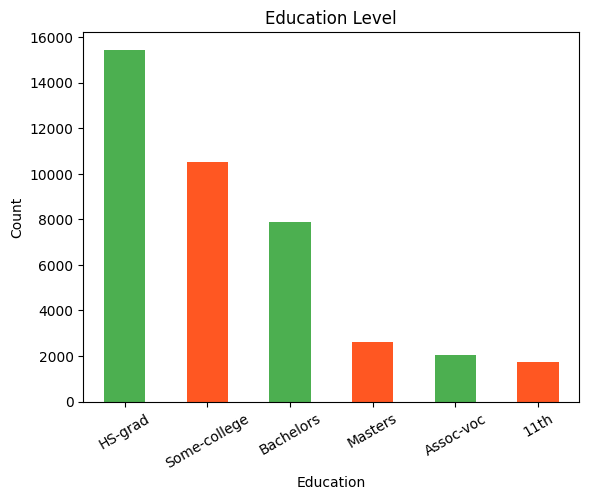

In [ ]:
# Sex distribution
df["sex"].value_counts().plot(kind="bar", color=["#4CAF50", "#FF5722"])
plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()
# Race distribution
df["race"].value_counts().plot(kind="bar", color=["#4CAF50", "#FF5722"])
plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()
# Education distribution
df["education"].value_counts().head(6).plot(kind="bar", color=["#4CAF50", "#FF5722"])
plt.title("Education Level")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

In [ ]:
# Preprocessing
# Clean missing values
df_clean = df.dropna().copy()

In [ ]:
# Feature selection
# Target varible
y = df_clean["income"]
# Drop the target column from the features
X = df_clean.drop(columns=["income", "income_label"], errors="ignore")
# One-hot encoding for categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
# Train/test split
# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# Train Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Fit the model using the training data
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [ ]:
# Import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC-ROC:", auc)

Accuracy: 0.8543832020997375
Precision: 0.7341128622267412
Recall: 0.6256499133448874
F1 Score: 0.6755555555555556
AUC-ROC: 0.9058768123790137


In [ ]:
# Disaggregated
# Create a test dataframe
df_test = X_test.copy()
df_test["actual"] = y_test
df_test["pred"] = y_pred
df_test["prob"] = y_prob
# Add gender column back from original dataframe
df_test["sex"] = df.loc[X_test.index, "sex"]
# Function to compute metrics
def compute_metrics(group):
    return pd.Series({
        "accuracy": accuracy_score(group["actual"], group["pred"]),
        "precision": precision_score(group["actual"], group["pred"]),
        "recall": recall_score(group["actual"], group["pred"]),
        "f1": f1_score(group["actual"], group["pred"]),
        "auc": roc_auc_score(group["actual"], group["prob"])
    })
# Apply the function to each gender group
metrics_by_gender = df_test.groupby("sex").apply(compute_metrics)
print(metrics_by_gender)

        accuracy  precision    recall        f1       auc
sex                                                      
Female  0.923607   0.717647  0.515493  0.600000  0.930178
Male    0.819460   0.736565  0.645673  0.688131  0.883943


/tmp/ipykernel_7067/3573270275.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_by_gender = df_test.groupby("sex").apply(compute_metrics)


**Phase 2: Fairness Audit and Explainability Analysis**

Fairness Analysis

In [ ]:
# Add group columns
df_test = X_test.copy()
df_test["actual"]= y_test
df_test["pred"]= y_pred
df_test["prob"]= y_prob
# Add protected attribute gender column
df_test["sex"] = df_clean.loc[X_test.index,"sex"]

In [ ]:
# Demographic parity
dp =df_test.groupby("sex")["pred"].mean()
print("Demographic Parity:\n",dp)

Demographic Parity:
 sex
Female    0.079837
Male      0.270415
Name: pred, dtype: float64


In [ ]:
# Equal opportunity
for gender in df_test["sex"].unique():
    a= df_test[df_test["sex"] == gender]
    b= recall_score(a["actual"], a["pred"])
    print(f"{gender} Equal Opportunity:", b)

Male Equal Opportunity: 0.6456733230926779
Female Equal Opportunity: 0.5154929577464789


In [ ]:
# Predictive parity
for gender in df_test["sex"].unique():
    a= df_test[df_test["sex"] == gender]
    c= precision_score(a["actual"], a["pred"])
    print(f"{gender} Predictive Parity:",c)

Male Predictive Parity: 0.7365654205607477
Female Predictive Parity: 0.7176470588235294


**Phase 2: Explainability Analysis**

In [ ]:
# Take a smaller sample
X_sample = X_test.sample(300, random_state=42)
# Create SHAP explainer for the model
explainer = shap.TreeExplainer(rf)
# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_sample)

In [ ]:
# Handle shape
if isinstance(shap_values, list):
    shap_class_1 = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_class_1 = shap_values[:, :, 1]
else:
    shap_class_1 = shap_values

In [ ]:
# Create mapping from encoded to original feature
feature_map = {}
for col in X_sample.columns:
    if "_" in col:
        feature_map[col] = col.split("_")[0]
    else:
        feature_map[col] = col
# Convert to DataFrame
shap_df = pd.DataFrame(shap_class_1, columns=X_sample.columns)
# Group SHAP values by original feature
shap_grouped = shap_df.groupby(feature_map, axis=1).sum()
# Also group input features
X_grouped = X_sample.copy()
X_grouped.columns = [feature_map[col] for col in X_sample.columns]
X_grouped = X_grouped.groupby(level=0, axis=1).mean()

/tmp/ipykernel_7067/197758229.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  shap_grouped = shap_df.groupby(feature_map, axis=1).sum()
/tmp/ipykernel_7067/197758229.py:15: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  X_grouped = X_grouped.groupby(level=0, axis=1).mean()


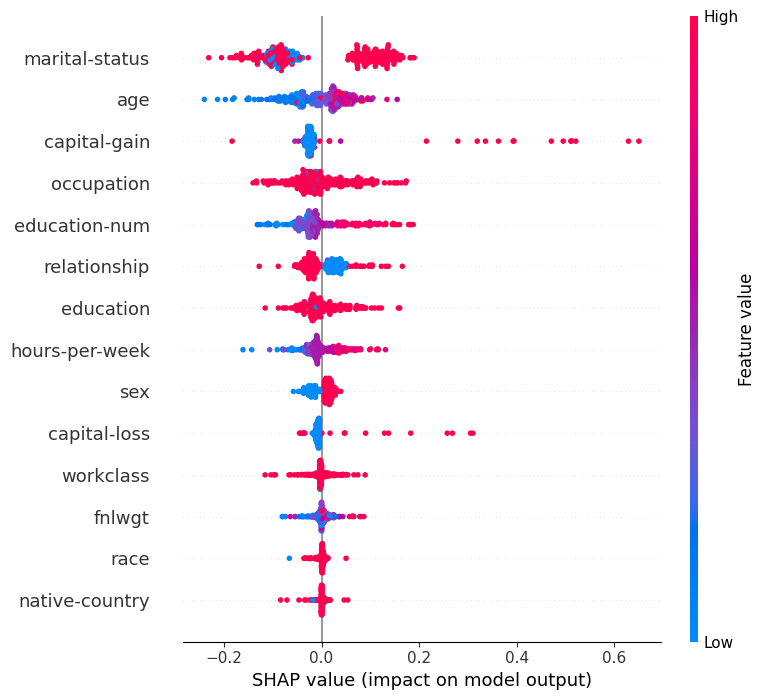

In [ ]:
# Beeswarm SHAP summary plot
shap.summary_plot(shap_grouped.values,X_grouped,feature_names=X_grouped.columns)

In [ ]:
# Find one unfavorable prediction, pred = 0 means <=50K
pred_low = df_test[df_test["pred"] == 0].index[0]

In [ ]:
# Show that person's information, decoded
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
original_test = df_clean.loc[X_test.index].reset_index(drop=True)
pred_low = np.where(y_pred == 0)[0][0]
print("=" * 60)
print(f"Sample #{pred_low} — Predicted: <=50K")
print("=" * 60)
for col in original_test.columns:
    if col not in ["income", "income_label"]:
        print(f"{col:<20} {original_test.loc[pred_low, col]}")
print("\nPrediction:", "<=50K" if y_pred[pred_low] == 0 else ">50K")
print("Actual:    ", "<=50K" if y_test_reset.iloc[pred_low] == 0 else ">50K")

Sample #0 — Predicted: <=50K
age                  23
workclass            Private
fnlwgt               197387
education            HS-grad
education-num        9
marital-status       Never-married
occupation           Craft-repair
relationship         Own-child
race                 White
sex                  Male
capital-gain         0
capital-loss         0
hours-per-week       37
native-country       Mexico

Prediction: <=50K
Actual:     <=50K


In [ ]:
# Original feature names
original_features = [
    "age", "workclass", "education", "education-num",
    "marital-status", "occupation", "relationship",
    "race", "sex", "hours-per-week", "native-country"]
# Map encoded columns back to original feature groups
feature_map = {}
for col in X_test.columns:
    if col.startswith("workclass_"):
        feature_map[col] = "workclass"
    elif col.startswith("education_"):
        feature_map[col] = "education"
    elif col.startswith("marital-status_"):
        feature_map[col] = "marital_status"
    elif col.startswith("occupation_"):
        feature_map[col] = "occupation"
    elif col.startswith("relationship_"):
        feature_map[col] = "relationship"
    elif col.startswith("race_"):
        feature_map[col] = "race"
    elif col.startswith("sex_"):
        feature_map[col] = "sex"
    elif col.startswith("native-country_"):
        feature_map[col] = "native_region"
    else:
        feature_map[col] = col

In [ ]:
# Convert SHAP values into a dataframe
shap_df = pd.DataFrame(shap_class_1, columns=X_test.columns)
# Group SHAP values by original feature
shap_grouped = shap_df.groupby(feature_map, axis=1).sum()
# Group feature values too
X_grouped = X_test.reset_index(drop=True).copy()
X_grouped.columns = [feature_map[col] for col in X_grouped.columns]
X_grouped = X_grouped.groupby(level=0, axis=1).mean()

/tmp/ipykernel_7067/4182402362.py:4: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  shap_grouped = shap_df.groupby(feature_map, axis=1).sum()
/tmp/ipykernel_7067/4182402362.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  X_grouped = X_grouped.groupby(level=0, axis=1).mean()


In [ ]:
# Get one scalar base value for class 1 (>50K)
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]
base_value = float(base_value)

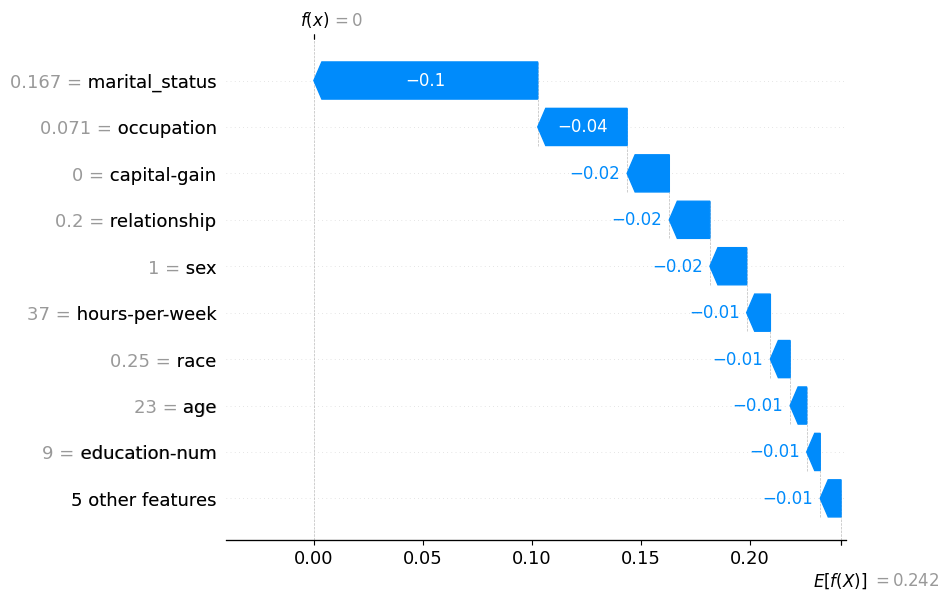

In [ ]:
# Waterfall plot
shap_exp_grouped = shap.Explanation(
    values=shap_grouped.iloc[pred_low].values,
    base_values=base_value,
    data=X_grouped.iloc[pred_low].values,
    feature_names=X_grouped.columns.tolist()
)

shap.plots.waterfall(shap_exp_grouped, max_display=10)

**References:**

Becker, B. & Kohavi, R. (1996). Adult [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.

OpenAI. (2026). ChatGPT (May 2026 version) [Large language model]. https://chat.openai.com